In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Create Mall Customers Dataset
np.random.seed(42)
n = 200
data = {
    'CustomerID':    range(1, n+1),
    'Gender':        np.random.choice(['Male','Female'], n),
    'Age':           np.random.randint(18, 70, n),
    'Annual_Income': np.random.randint(15, 140, n),
}
# Spending score based on income pattern with clusters
spending = []
for inc in data['Annual_Income']:
    if inc < 40:
        spending.append(np.random.randint(40, 100))
    elif inc < 80:
        spending.append(np.random.randint(20, 60))
    else:
        spending.append(np.random.randint(1, 40))
data['Spending_Score'] = spending

df = pd.DataFrame(data)
print("✅ Dataset Created!")
print("Shape:", df.shape)
df.head()

✅ Dataset Created!
Shape: (200, 5)


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,49,68,41
1,2,Female,56,22,96
2,3,Male,66,41,48
3,4,Male,69,41,33
4,5,Male,49,112,28


In [2]:
X = df[['Annual_Income', 'Spending_Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Feature Scaling Done!")
print("Before scaling - Mean:", round(X.mean().mean(), 2))
print("After  scaling - Mean:", round(X_scaled.mean(), 4))
print("After  scaling - Std :", round(X_scaled.std(), 2))

✅ Feature Scaling Done!
Before scaling - Mean: 57.83
After  scaling - Mean: 0.0
After  scaling - Std : 1.0


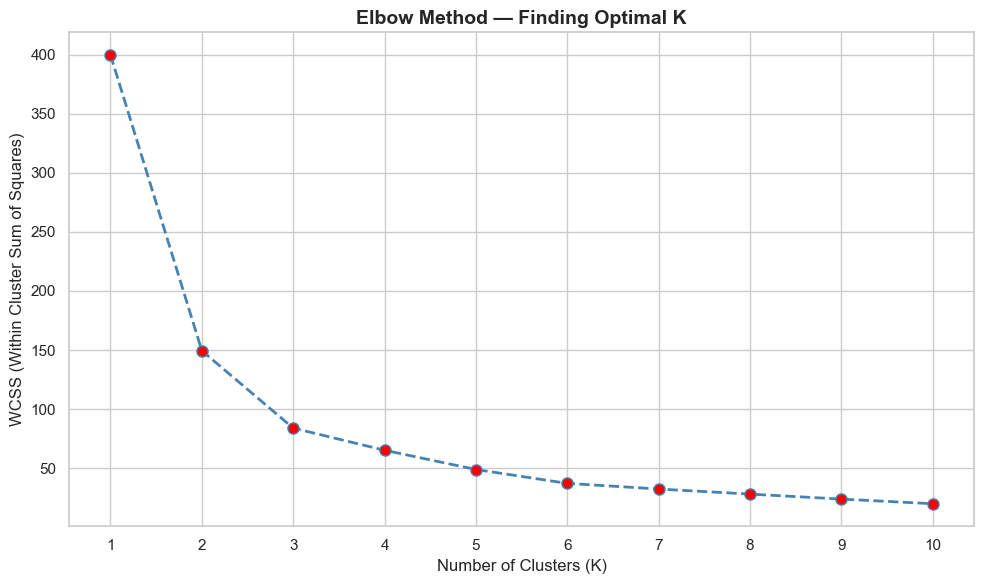

✅ Elbow Curve plotted!
Look for the 'elbow' point — usually K=4 or K=5


In [3]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++',
                     random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, color='steelblue',
         linestyle='--', marker='o',
         markerfacecolor='red', markersize=8, linewidth=2)
plt.title('Elbow Method — Finding Optimal K',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("✅ Elbow Curve plotted!")
print("Look for the 'elbow' point — usually K=4 or K=5")

In [4]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init='k-means++',
                 random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(f"✅ K-Means Trained with K = {optimal_k}")
print("\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

✅ K-Means Trained with K = 5

Cluster Distribution:
Cluster
0    43
1    22
2    40
3    56
4    39
Name: count, dtype: int64


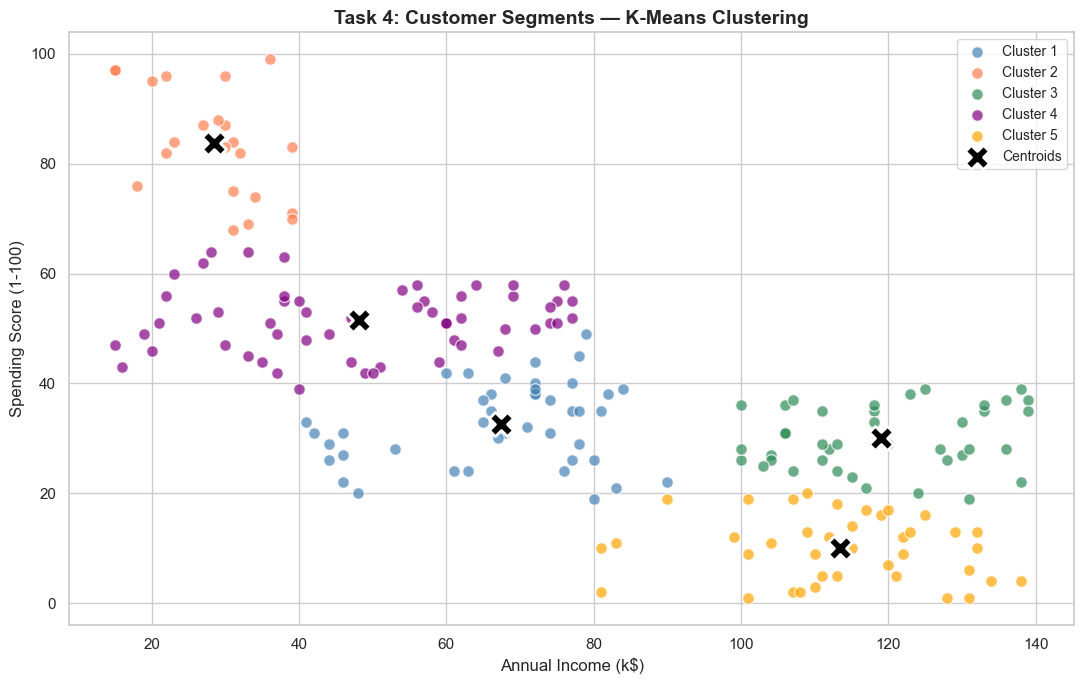

✅ Clusters and Centroids Visualized!


In [5]:
plt.figure(figsize=(11, 7))

colors = ['steelblue', 'coral', 'seagreen', 'purple', 'orange']

for i in range(optimal_k):
    cluster_data = X[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual_Income'],
                cluster_data['Spending_Score'],
                s=70, alpha=0.7, color=colors[i],
                label=f'Cluster {i+1}', edgecolors='white')

# Plot centroids (convert back to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=300, c='black', marker='X',
            label='Centroids', edgecolors='white', linewidth=2)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Task 4: Customer Segments — K-Means Clustering',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("✅ Clusters and Centroids Visualized!")

In [6]:
sil_score = silhouette_score(X_scaled, clusters)

print("=" * 45)
print("      SILHOUETTE SCORE EVALUATION")
print("=" * 45)
print(f"✅ Silhouette Score : {sil_score:.4f}")
print("=" * 45)

if sil_score > 0.7:
    quality = "Excellent — clusters are well separated"
elif sil_score > 0.5:
    quality = "Good — clusters are reasonably separated"
elif sil_score > 0.25:
    quality = "Fair — some overlap between clusters"
else:
    quality = "Poor — clusters overlap significantly"

print(f"Interpretation: {quality}")
print("\nScore Range Guide:")
print("  1.0  = Perfect clustering")
print("  0.5+ = Good clustering")
print("  0.0  = Overlapping clusters")
print(" -1.0  = Wrong clustering")

      SILHOUETTE SCORE EVALUATION
✅ Silhouette Score : 0.4114
Interpretation: Fair — some overlap between clusters

Score Range Guide:
  1.0  = Perfect clustering
  0.5+ = Good clustering
  0.0  = Overlapping clusters
 -1.0  = Wrong clustering


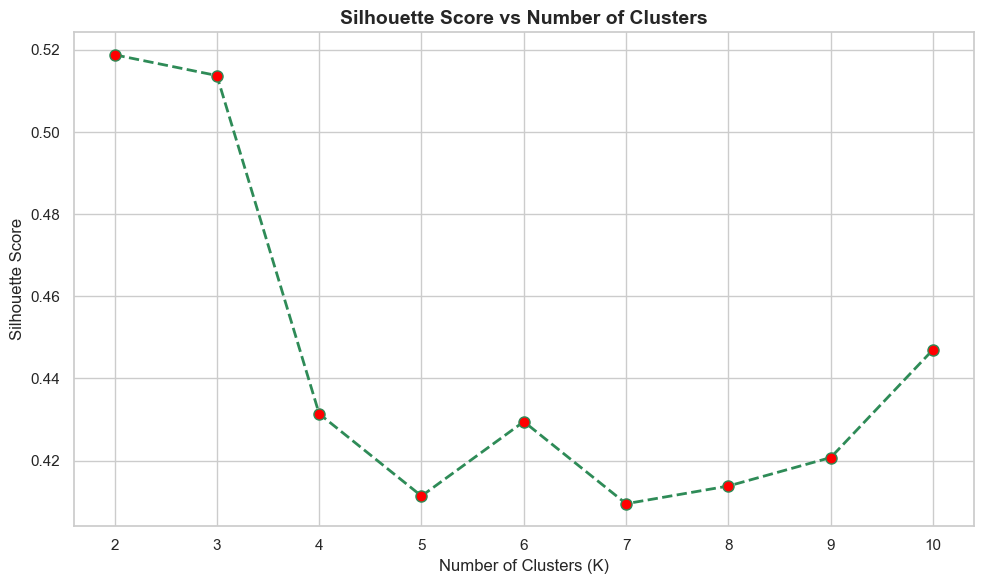

✅ Best K based on Silhouette Score: 2


In [7]:
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++',
                random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10, 6))
plt.plot(k_values, sil_scores, color='seagreen',
         linestyle='--', marker='o',
         markerfacecolor='red', markersize=8, linewidth=2)
plt.title('Silhouette Score vs Number of Clusters',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = list(k_values)[np.argmax(sil_scores)]
print(f"✅ Best K based on Silhouette Score: {best_k}")

In [8]:
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual_Income': 'mean',
    'Spending_Score': 'mean',
    'CustomerID': 'count'
}).round(1)
cluster_summary.columns = ['Avg_Age', 'Avg_Income', 'Avg_Spending', 'Count']

print("=" * 60)
print("         CUSTOMER SEGMENT PROFILES")
print("=" * 60)
print(cluster_summary)
print("=" * 60)

labels_map = {
    0: 'Careful Spenders',
    1: 'Target Customers (High Income, High Spending)',
    2: 'Standard Customers',
    3: 'Sensible Customers (Low Income, Low Spending)',
    4: 'Careless Customers (High Income, Low Spending)'
}
print("\nSegment Descriptions:")
for i in range(optimal_k):
    print(f"  Cluster {i+1}: {labels_map.get(i, 'Custom Segment')}")

         CUSTOMER SEGMENT PROFILES
         Avg_Age  Avg_Income  Avg_Spending  Count
Cluster                                          
0           45.7        67.5          32.7     43
1           46.0        28.5          83.8     22
2           41.9       119.0          30.0     40
3           44.5        48.1          51.5     56
4           44.5       113.4          10.0     39

Segment Descriptions:
  Cluster 1: Careful Spenders
  Cluster 2: Target Customers (High Income, High Spending)
  Cluster 3: Standard Customers
  Cluster 4: Sensible Customers (Low Income, Low Spending)
  Cluster 5: Careless Customers (High Income, Low Spending)



INTERVIEW QUESTIONS — ANSWERS
══════════════════════════════════════════════════════

Q1. Supervised vs Unsupervised?
    Supervised   = Data has labels (input + output known)
                   Example: Classification, Regression
    Unsupervised = Data has NO labels (only input)
                   Model finds hidden patterns itself
                   Example: Clustering (K-Means)

Q2. K-Means Logic?
    1. Choose number of clusters K
    2. Randomly place K centroids
    3. Assign each point to nearest centroid
    4. Recalculate centroid as mean of assigned points
    5. Repeat steps 3-4 until centroids stop moving
    Goal: Minimize distance within clusters (WCSS)

Q3. How Elbow Method works?
    1. Run K-Means for K = 1 to 10
    2. Calculate WCSS for each K
    3. Plot K vs WCSS
    4. Find the 'elbow' point where WCSS stops
       decreasing sharply
    5. That point = Optimal K value

Q4. Scaling importance for clustering?
    K-Means uses DISTANCE to assign clusters.
    If features have different ranges:
    - Large value features dominate distance calculation
    - Clusters become biased and incorrect
    After StandardScaler:
    - All features contribute equally
    - Clusters are accurate and meaningful
    Scaling is ESSENTIAL for K-Means.
